In [ ]:
import pandas as pd
import numpy as np
import os
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# ---------------------------------------------------------
# Step 1: 데이터 로드 및 지표 추출 (Master + 상세 CSV)
# ---------------------------------------------------------

In [10]:
# 1-1. 마스터 DOE 로드 (P1~P6 조건)
master_df = pd.read_csv('Master_DOE_1200.csv')

In [11]:
# 1-2. 상세 파일 경로 설정
path = 'D:\AI_Study\GitHub\Battery\데이터셋'
combined_data = []

print("상세 파일에서 'Die_SY_Max'의 절댓값 최대치 추출 중...")

for i, row in master_df.iterrows():
    # 파일명 규칙: ML_DATA_Extract_Row_0.csv ...
    file_path = os.path.join(path, f'ML_DATA_Extract_Row_{i}.csv')
    
    if os.path.exists(file_path):
        # 상세 데이터 로드
        temp_df = pd.read_csv(file_path)
        
        # 'Die_SY_Max' 컬럼의 절댓값 중 최대값을 추출 (Target Y 생성)
        # 컬럼명에 공백이 있을 수 있으니 strip() 처리 혹은 정확한 명칭 사용
        target_val = temp_df[' Die_SY_Max'].abs().max() 
        
        # 마스터 데이터(P1~P6)와 추출한 Target 결합
        row_dict = row.to_dict()
        row_dict['Target_Max_Peak'] = target_val
        combined_data.append(row_dict)

상세 파일에서 'Die_SY_Max'의 절댓값 최대치 추출 중...


In [12]:
# 학습용 최종 데이터프레임
df_final = pd.DataFrame(combined_data)
print(f"매칭 완료된 데이터 수: {len(df_final)}개")

매칭 완료된 데이터 수: 361개


# ---------------------------------------------------------
# Step 2: EDA
# ---------------------------------------------------------

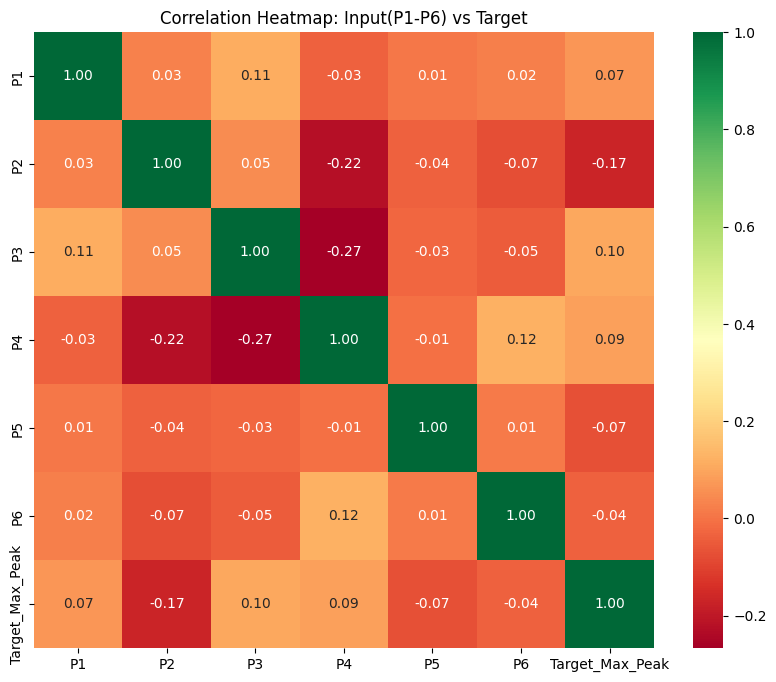

In [13]:
# P1~P6와 Target 간의 상관관계 확인
plt.figure(figsize=(10, 8))
sns.heatmap(df_final.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title("Correlation Heatmap: Input(P1-P6) vs Target")
plt.show()

# ---------------------------------------------------------
# Step 3: 대리 모델(Surrogate) 학습 - XGBoost
# ---------------------------------------------------------

In [14]:
features = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']
X = df_final[features]
y = df_final['Target_Max_Peak']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# 모델 최적화 (파라미터는 필요에 따라 조정 가능)
model = xgb.XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.05, 
    max_depth=6, 
    subsample=0.8,
    random_state=42
)
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [16]:
# 검증 성능 출력
y_pred = model.predict(X_test)
print(f"R2 Score (결정계수): {r2_score(y_test, y_pred):.4f}")
print(f"MAE (평균 절대 오차): {mean_absolute_error(y_test, y_pred):.4f}")

R2 Score (결정계수): -0.0938
MAE (평균 절대 오차): 5.8028


# ---------------------------------------------------------
# Step 4: Monte Carlo Simulation (10만 개 증강)
# ---------------------------------------------------------

In [17]:
print("\n몬테카를로 시뮬레이션 시작 (100,000 samples)...")
n_virtual = 100000


몬테카를로 시뮬레이션 시작 (100,000 samples)...


In [18]:
# 기존 P1~P6의 최소/최대 범위 내에서 무작위 난수 생성
virtual_input = pd.DataFrame()
for col in features:
    virtual_input[col] = np.random.uniform(X[col].min(), X[col].max(), n_virtual)

In [19]:
# 학습된 XGBoost 대리 모델로 가상 Y값 예측
virtual_input['Predicted_Max_Peak'] = model.predict(virtual_input)

print("데이터 증강 완료!")

데이터 증강 완료!


# ---------------------------------------------------------
# Step 5: 결과 시각화 및 저장
# ---------------------------------------------------------

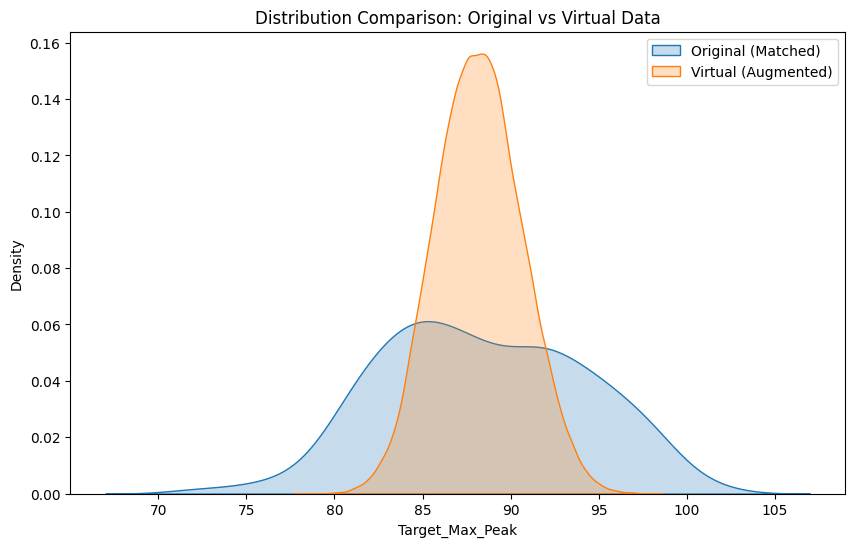

In [20]:
# 원본 데이터와 가상 데이터의 분포 비교
plt.figure(figsize=(10, 6))
sns.kdeplot(df_final['Target_Max_Peak'], label='Original (Matched)', fill=True)
sns.kdeplot(virtual_input['Predicted_Max_Peak'], label='Virtual (Augmented)', fill=True)
plt.title("Distribution Comparison: Original vs Virtual Data")
plt.legend()
plt.show()

In [21]:
# 최종 가상 데이터셋 저장
# virtual_input.to_csv('Augmented_Surrogate_Data_100k.csv', index=False)